# Getting started with tard

A graph neural network turns node attributes $X$ into learned representations $Z$. `tard` asks where, and at which topological distance, that step changed how similar nodes are to each other.

## 1. Load the example graph

A small synthetic graph with 20 nodes in two communities joined by two bridge edges. The attributes and embeddings were constructed so that each region shows a different effect:

| region | nodes | attributes | planted change in the embeddings |
|---|---|---|---|
| `stable` | n01–n05 | homophilic | none |
| `compressed` | n06–n10 | homophilic, more varied | pulled towards their region's mean |
| `mixed` | n11–n16 | heterophilic, two alternating types | mixed with their neighbours |
| `separated` | n17–n20 | homophilic | neighbours pushed in opposite directions |

In [1]:
%config InlineBackend.figure_formats = ["retina"]

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

import tard

plt.rcParams.update(tard.visualization.STYLE)

nodes = pd.read_csv("../data/nodes.csv", index_col="node")
edges = pd.read_csv("../data/edges.csv")
attributes = pd.read_csv("../data/attributes.csv", index_col="node")
embeddings = pd.read_csv("../data/embeddings.csv", index_col="node")

graph = nx.from_pandas_edgelist(edges, "source", "target")
nodes.join(attributes).head()

,community,region,x1,x2,x3
node,,,,,
n01,A,stable,1.00,0.84,-0.43
n02,A,stable,0.89,0.75,-0.52
n03,A,stable,1.01,0.96,-0.46
n04,A,stable,0.93,0.86,-0.36
n05,A,stable,1.01,0.69,-0.40


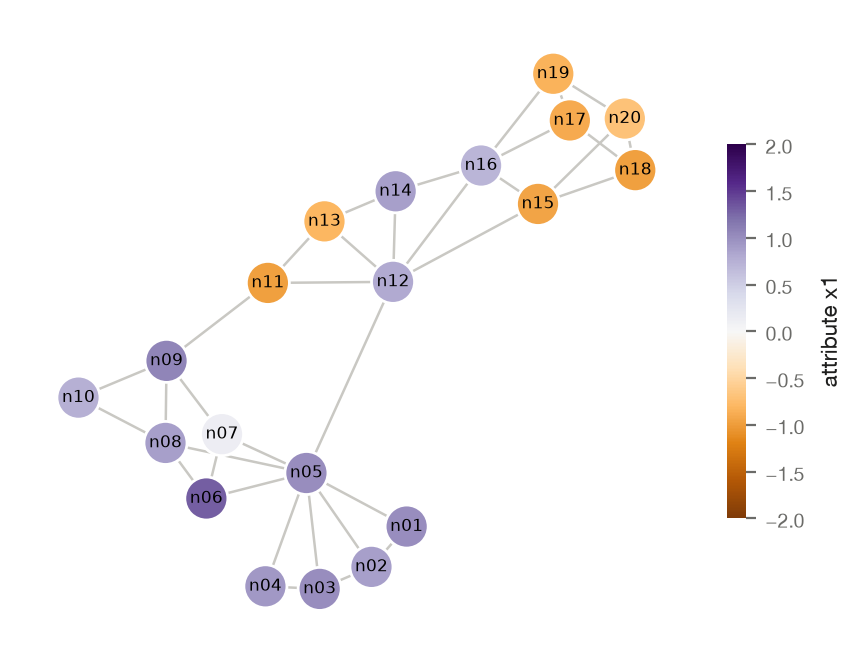

In [2]:
positions = nx.spring_layout(graph, seed=25)

fig, ax = plt.subplots(figsize=(4.2, 3.2), layout="constrained")
nx.draw_networkx_edges(graph, positions, ax=ax, edge_color="#c9c8c3", width=0.9)
drawn_nodes = nx.draw_networkx_nodes(
    graph,
    positions,
    ax=ax,
    node_color=attributes.loc[list(graph.nodes), "x1"],
    cmap="PuOr",
    vmin=-2.0,
    vmax=2.0,
    node_size=240,
    edgecolors="white",
    linewidths=1.0,
)
nx.draw_networkx_labels(graph, positions, ax=ax, font_size=6)
fig.colorbar(drawn_nodes, ax=ax, shrink=0.6, label="attribute x1").outline.set_visible(False)
ax.set_axis_off()

## 2. Compute distortion

In [3]:
result = tard.compute(
    graph=graph,
    attributes=attributes,
    embeddings=embeddings,
    max_hops=4,
)
result.distortion.round(2)

,1-hop,2-hop,3-hop,4-hop
n01,0.00,0.09,0.04,0.02
n02,0.00,0.12,0.05,0.02
n03,0.00,0.10,0.04,0.01
n04,0.00,0.08,0.04,0.01
n05,0.07,0.06,0.03,NaN
n06,0.15,0.17,0.24,0.19
n07,0.29,0.33,0.22,0.02
n08,0.08,0.20,0.28,0.12
n09,0.15,0.18,0.05,0.04
n10,0.14,0.23,0.16,0.20


In [4]:
result.global_distortion

0.23417278950481507

## 3. Distortion map

Each row is a node, each column a topological distance. A cell is the mean absolute change in similarity between the node and the nodes exactly that many hops away. Hatched cells have no nodes at that distance.

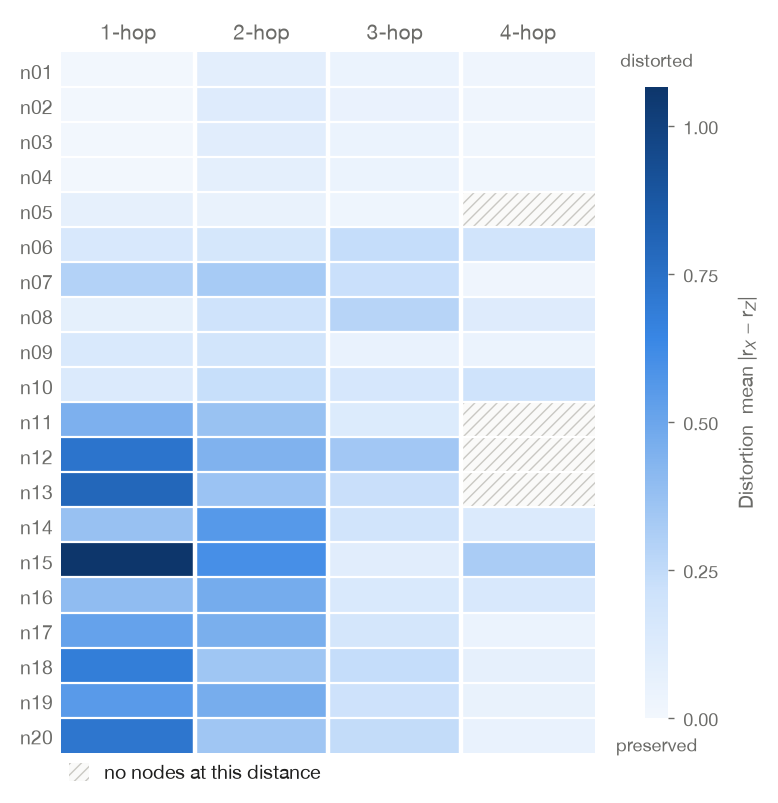

In [5]:
fig, ax = tard.plot_distortion_map(result)

The `stable` region (n01–n05) stays close to zero at 1 hop, while the `mixed` and `separated` regions change most among direct neighbours.

## 4. Signed relational change

The same matrix with the direction of the change:

- negative: the pair became less similar in the embedding
- zero: the relationship is approximately preserved
- positive: the pair became more similar in the embedding

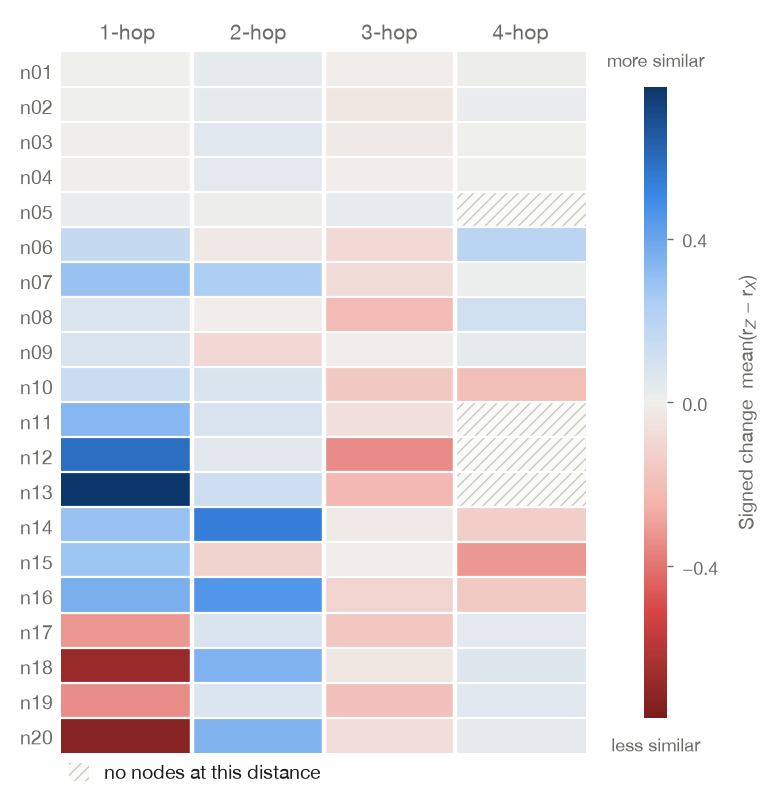

In [6]:
fig, ax = tard.plot_signed_map(result)

The two regions with high distortion differ in direction: heterophilic neighbours in the `mixed` region were pulled together, while neighbours in the `separated` region were pushed apart.

## 5. Inspect one node

Node n13 sits in the heterophilic region. Its direct neighbours became much more similar, while nodes three hops away became less similar.

In [7]:
node = "n13"
result.distortion.loc[node]

1-hop    0.797845
2-hop    0.364507
3-hop    0.227993
4-hop         NaN
Name: n13, dtype: float64

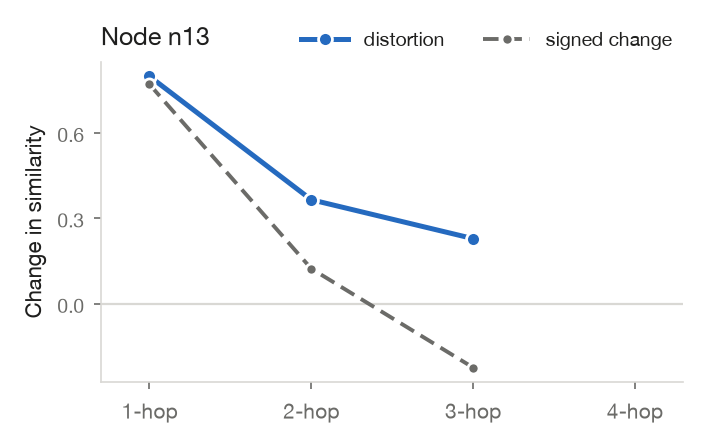

In [8]:
fig, ax = tard.plot_node_profile(result, node)

The results are ordinary DataFrames, so group profiles are plain pandas operations. Mean distortion per region:

In [9]:
result.distortion.groupby(nodes["region"]).mean().round(2)

,1-hop,2-hop,3-hop,4-hop
region,,,,
compressed,0.16,0.22,0.19,0.11
mixed,0.64,0.47,0.19,0.20
separated,0.62,0.41,0.22,0.05
stable,0.01,0.09,0.04,0.02
